In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df=pd.read_csv('Road_Accident_Prevention_Clean.csv')

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Accident_ID        20000 non-null  str    
 1   Date               20000 non-null  str    
 2   Time               20000 non-null  str    
 3   State              20000 non-null  str    
 4   District           20000 non-null  str    
 5   Latitude           20000 non-null  float64
 6   Longitude          20000 non-null  float64
 7   Road_Type          20000 non-null  str    
 8   Weather            20000 non-null  str    
 9   Light_Condition    20000 non-null  str    
 10  Driver_Age         20000 non-null  int64  
 11  Driver_Gender      20000 non-null  str    
 12  Vehicle_Type       20000 non-null  str    
 13  Speed_kmph         20000 non-null  int64  
 14  Alcohol_Involved   20000 non-null  str    
 15  Driver_Drowsy      20000 non-null  str    
 16  Pothole_Involved   20000 non-null

In [5]:
df.shape

(20000, 20)

In [6]:
df1=df.copy()

In [7]:
df1.info()

<class 'pandas.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Accident_ID        20000 non-null  str    
 1   Date               20000 non-null  str    
 2   Time               20000 non-null  str    
 3   State              20000 non-null  str    
 4   District           20000 non-null  str    
 5   Latitude           20000 non-null  float64
 6   Longitude          20000 non-null  float64
 7   Road_Type          20000 non-null  str    
 8   Weather            20000 non-null  str    
 9   Light_Condition    20000 non-null  str    
 10  Driver_Age         20000 non-null  int64  
 11  Driver_Gender      20000 non-null  str    
 12  Vehicle_Type       20000 non-null  str    
 13  Speed_kmph         20000 non-null  int64  
 14  Alcohol_Involved   20000 non-null  str    
 15  Driver_Drowsy      20000 non-null  str    
 16  Pothole_Involved   20000 non-null

In [8]:
print(df1['Driver_Age'].head())

print(df1['Driver_Age'].dtype)

0    18
1    34
2    47
3    53
4    38
Name: Driver_Age, dtype: int64
int64


In [9]:
print(df1['Driver_Age'].describe())

count    20000.000000
mean        36.596600
std         12.132243
min         18.000000
25%         27.000000
50%         36.000000
75%         45.000000
max         75.000000
Name: Driver_Age, dtype: float64


In [10]:
print("Mean Age :", df1['Driver_Age'].mean())
print("Median Age :", df1['Driver_Age'].median())
print("Mode Age :", df1['Driver_Age'].mode()[0])
print("Minimum Age :", df1['Driver_Age'].min())
print("Maximum Age :", df1['Driver_Age'].max())
print("Variance :", df1['Driver_Age'].var())
print("Standard Deviation :", df1['Driver_Age'].std())
print("Skewness :", df1['Driver_Age'].skew())
print("Kurtosis :", df1['Driver_Age'].kurt())

Mean Age : 36.5966
Median Age : 36.0
Mode Age : 18
Minimum Age : 18
Maximum Age : 75
Variance : 147.19132800640034
Standard Deviation : 12.132243321265872
Skewness : 0.3396386506444566
Kurtosis : -0.4078961432023043


#### Driver Age by State

In [11]:
state_analysis = df1.groupby('State')['Driver_Age'].agg(
    Count='count',
    Mean='mean',
    Median='median',
    Minimum='min',
    Maximum='max',
    Std='std'
)

print(state_analysis)

                Count       Mean  Median  Minimum  Maximum        Std
State                                                                
Andhra Pradesh   3172  36.595523    36.0       18       75  12.243664
Karnataka        4440  36.259459    36.0       18       75  12.121142
Kerala           3120  36.776923    36.0       18       75  12.087619
Puducherry        756  37.673280    37.5       18       75  12.488527
Tamil Nadu       4851  36.262008    36.0       18       75  12.016295
Telangana        3661  37.073750    37.0       18       75  12.141111


#### Driver Age by Driver_Gender

In [26]:
gender_analysis = df1.groupby('Driver_Gender')['Driver_Age'].agg(
    Count='count',
    Mean='mean',
    Median='median',
    Minimum='min',
    Maximum='max'
)

print(gender_analysis)

               Count       Mean  Median  Minimum  Maximum
Driver_Gender                                            
Female          4360  36.575688    36.0       18       75
Male           15640  36.602430    36.0       18       75


#### Derive Date Parts

In [12]:
df1['Date'] = pd.to_datetime(df1['Date'])

In [13]:
df1['Year'] = df1['Date'].dt.year

df1['Month'] = df1['Date'].dt.month

df1['Month_Name'] = df1['Date'].dt.month_name()

df1['Day'] = df1['Date'].dt.day

df1['Day_Name'] = df1['Date'].dt.day_name()


In [14]:
df1.head()

,Accident_ID,Date,Time,State,District,Latitude,Longitude,Road_Type,Weather,Light_Condition,...,Driver_Drowsy,Pothole_Involved,Cause_of_Accident,Severity,Casualties,Year,Month,Month_Name,Day,Day_Name
0,ACC20000,2023-01-18,12:39,Tamil Nadu,Madurai,11.2765,78.0398,Village Road,Rainy,Day,...,No,No,Poor Weather Visibility,Low,2,2023,1,January,18,Wednesday
1,ACC20001,2023-10-16,18:13,Andhra Pradesh,Guntur,16.2785,79.6676,National Highway,Cloudy,Dusk,...,No,No,Over Speeding,Medium,0,2023,10,October,16,Monday
2,ACC20002,2024-05-17,14:28,Karnataka,Mysuru,14.4623,75.0246,Village Road,Rainy,Day,...,No,Yes,Poor Weather Visibility,High,7,2024,5,May,17,Friday
3,ACC20003,2023-05-15,7:54,Andhra Pradesh,Visakhapatnam,15.6972,80.1319,National Highway,Cloudy,Day,...,No,No,Poor Weather Visibility,Medium,3,2023,5,May,15,Monday
4,ACC20004,2023-11-08,9:05,Puducherry,Puducherry,11.7264,80.7346,State Highway,Cloudy,Day,...,No,No,Over Speeding,Low,1,2023,11,November,8,Wednesday


#### Convert Time Column

In [15]:
df1['Time'] = pd.to_datetime(df1['Time']).dt.strftime('%H:%M:%S')

C:\Users\Sree Praneeth Simha\AppData\Local\Temp\ipykernel_17544\2412363071.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df1['Time'] = pd.to_datetime(df1['Time']).dt.strftime('%H:%M:%S')


In [16]:
# Convert to datetime
df1['Time'] = pd.to_datetime(df1['Time'])

# Extract parts
df1['Hour'] = df1['Time'].dt.hour
df1['Minute'] = df1['Time'].dt.minute
df1['Second'] = df1['Time'].dt.second

# Finally display only HH:MM:SS
df1['Time'] = df1['Time'].dt.strftime('%H:%M:%S')

C:\Users\Sree Praneeth Simha\AppData\Local\Temp\ipykernel_17544\4125828426.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df1['Time'] = pd.to_datetime(df1['Time'])


In [17]:
df1.head()

,Accident_ID,Date,Time,State,District,Latitude,Longitude,Road_Type,Weather,Light_Condition,...,Severity,Casualties,Year,Month,Month_Name,Day,Day_Name,Hour,Minute,Second
0,ACC20000,2023-01-18,12:39:00,Tamil Nadu,Madurai,11.2765,78.0398,Village Road,Rainy,Day,...,Low,2,2023,1,January,18,Wednesday,12,39,0
1,ACC20001,2023-10-16,18:13:00,Andhra Pradesh,Guntur,16.2785,79.6676,National Highway,Cloudy,Dusk,...,Medium,0,2023,10,October,16,Monday,18,13,0
2,ACC20002,2024-05-17,14:28:00,Karnataka,Mysuru,14.4623,75.0246,Village Road,Rainy,Day,...,High,7,2024,5,May,17,Friday,14,28,0
3,ACC20003,2023-05-15,07:54:00,Andhra Pradesh,Visakhapatnam,15.6972,80.1319,National Highway,Cloudy,Day,...,Medium,3,2023,5,May,15,Monday,7,54,0
4,ACC20004,2023-11-08,09:05:00,Puducherry,Puducherry,11.7264,80.7346,State Highway,Cloudy,Day,...,Low,1,2023,11,November,8,Wednesday,9,5,0


##### Outlier Analysis using IQR

In [18]:
Q1 = df1['Driver_Age'].quantile(0.25)

Q3 = df1['Driver_Age'].quantile(0.75)

IQR = Q3 - Q1

print("Q1 :",Q1)
print("Q3 :",Q3)
print("IQR :",IQR)

Q1 : 27.0
Q3 : 45.0
IQR : 18.0


In [19]:
lower_limit = Q1 - 1.5 * IQR



upper_limit = Q3 + 1.5 * IQR

print("Lower Limit :",lower_limit)
print("Upper Limit :",upper_limit)

Lower Limit : 0.0
Upper Limit : 72.0


In [20]:
outliers_iqr = df1[
    (df1['Driver_Age'] < lower_limit) |
    (df1['Driver_Age'] > upper_limit)
]

print(outliers_iqr)

      Accident_ID         Date      Time           State         District  \
219        ACC20219 2024-07-12  20:31:00      Tamil Nadu          Madurai   
260        ACC20260 2022-10-25  16:55:00      Puducherry         Karaikal   
827        ACC20827 2023-04-25  08:56:00       Karnataka  Bengaluru Urban   
1083       ACC21083 2024-12-10  11:57:00      Puducherry         Karaikal   
1291       ACC21291 2024-11-24  14:22:00      Puducherry       Puducherry   
1381       ACC21381 2023-06-09  09:36:00       Karnataka         Hubballi   
1390       ACC21390 2023-05-26  12:12:00       Telangana         Warangal   
1676       ACC21676 2024-07-26  15:01:00       Telangana       Karimnagar   
1816       ACC21816 2023-08-02  09:37:00          Kerala           Kollam   
2010       ACC22010 2022-03-11  16:58:00       Telangana        Hyderabad   
2172       ACC22172 2023-09-25  18:44:00       Karnataka        Mangaluru   
2422       ACC22422 2022-06-08  19:12:00      Tamil Nadu          Madurai   

In [21]:
print("Number of Outliers :",len(outliers_iqr))

Number of Outliers : 57


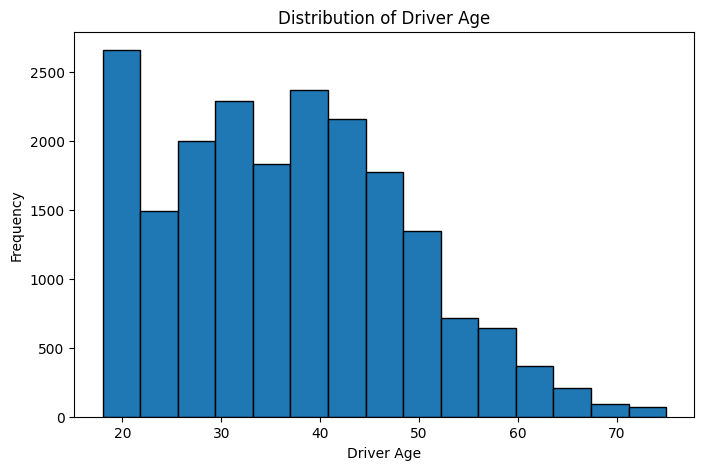

In [22]:
plt.figure(figsize=(8,5))

plt.hist(df1['Driver_Age'],
         bins=15,
         edgecolor='black')

plt.title("Distribution of Driver Age")

plt.xlabel("Driver Age")
plt.ylabel("Frequency")
plt.show()

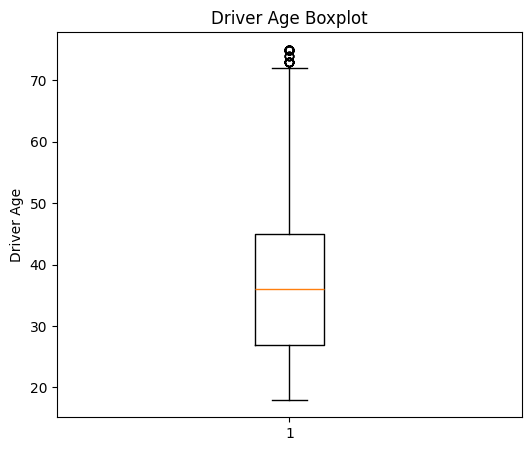

In [23]:
plt.figure(figsize=(6,5))

plt.boxplot(df1['Driver_Age'])

plt.title("Driver Age Boxplot")

plt.ylabel("Driver Age")

plt.show()

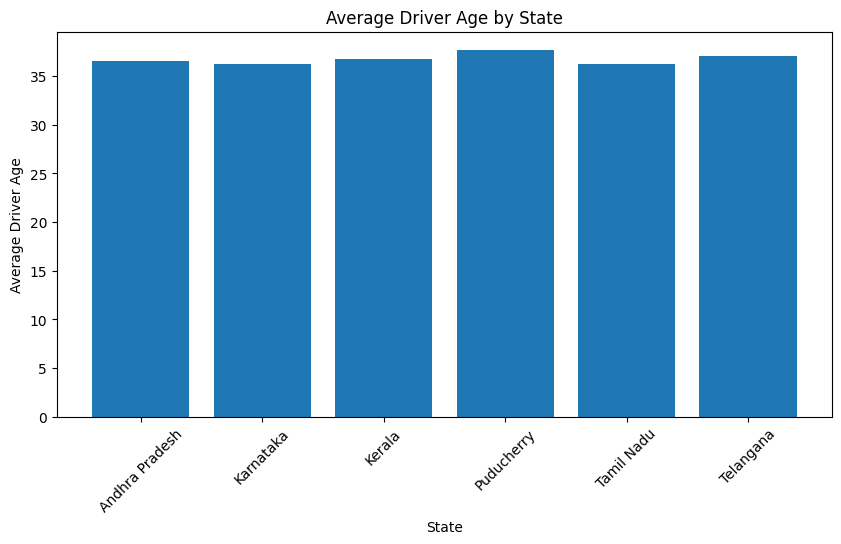

In [24]:
state_age = df1.groupby('State')['Driver_Age'].mean()

plt.figure(figsize=(10,5))

plt.bar(state_age.index,
        state_age.values)

plt.title("Average Driver Age by State")

plt.xlabel("State")

plt.ylabel("Average Driver Age")

plt.xticks(rotation=45)

plt.show()

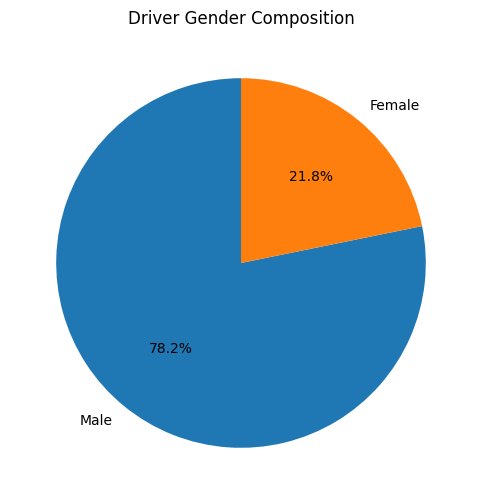

In [25]:
gender = df1['Driver_Gender'].value_counts()

plt.figure(figsize=(6,6))

plt.pie(gender.values,
        labels=gender.index,
        autopct='%1.1f%%',
        startangle=90)

plt.title("Driver Gender Composition")

plt.show()

### 5 Dataset grounded insights

-- The Driver_Age distribution is concentrated between approximately 25 and 45 years, indicating that most accidents involve middle-aged drivers.

-- The box plot highlights a few unusually young or old drivers as outliers, suggesting rare age groups involved in accidents.

-- The IQR method identifies drivers whose ages fall outside the normal range, while the Z-score method detects only extreme outliers, making it more conservative.

-- The average driver age varies across states, indicating regional differences in the age profile of drivers involved in accidents.

-- The gender composition chart shows which gender accounts for the larger share of accident records, helping identify the dominant demographic in the dataset.

#### Day-14

In [27]:
print(df1['Driver_Age'].describe())

count    20000.000000
mean        36.596600
std         12.132243
min         18.000000
25%         27.000000
50%         36.000000
75%         45.000000
max         75.000000
Name: Driver_Age, dtype: float64


In [28]:
print("Mean Age :", df1['Driver_Age'].mean())
print("Median Age :", df1['Driver_Age'].median())
print("Mode Age :", df1['Driver_Age'].mode()[0])
print("Minimum Age :", df1['Driver_Age'].min())
print("Maximum Age :", df1['Driver_Age'].max())
print("Variance :", df1['Driver_Age'].var())
print("Standard Deviation :", df1['Driver_Age'].std())
print("Skewness :", df1['Driver_Age'].skew())
print("Kurtosis :", df1['Driver_Age'].kurt())

Mean Age : 36.5966
Median Age : 36.0
Mode Age : 18
Minimum Age : 18
Maximum Age : 75
Variance : 147.19132800640034
Standard Deviation : 12.132243321265872
Skewness : 0.3396386506444566
Kurtosis : -0.4078961432023043


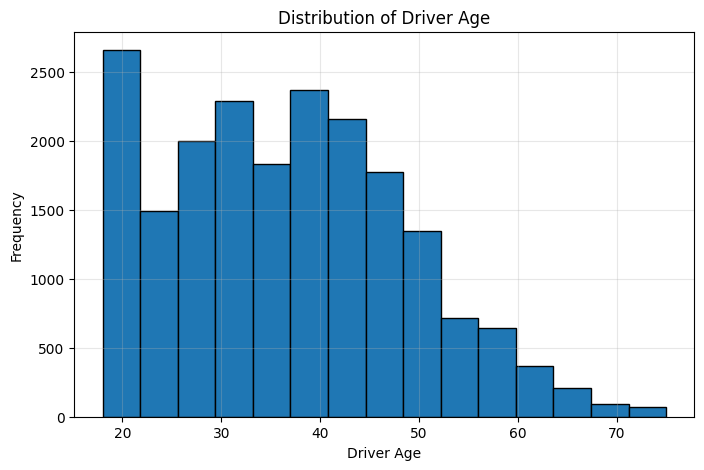

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(df['Driver_Age'],
         bins=15,
         edgecolor='black')

plt.title("Distribution of Driver Age")
plt.xlabel("Driver Age")
plt.ylabel("Frequency")

plt.grid(alpha=0.3)

plt.show()

In [30]:
skew = df['Driver_Age'].skew()

print("Skewness :", skew)

if skew > 0:
    print("The distribution is Positively Skewed (Right Skewed).")
elif skew < 0:
    print("The distribution is Negatively Skewed (Left Skewed).")
else:
    print("The distribution is Symmetric.")

Skewness : 0.3396386506444566
The distribution is Positively Skewed (Right Skewed).


In [31]:
kurt = df['Driver_Age'].kurt()

print("Kurtosis :", kurt)

if kurt > 0:
    print("The distribution is Leptokurtic (Heavy Tails).")
elif kurt < 0:
    print("The distribution is Platykurtic (Light Tails).")
else:
    print("The distribution is Mesokurtic (Normal Distribution).")

Kurtosis : -0.4078961432023043
The distribution is Platykurtic (Light Tails).


-- The dataset contains only recorded road accident cases and may not represent all accidents that occurred.

-- Driver ages are limited to the available records, so the results cannot be generalized to the entire driving population.

-- If the data covers only specific states or regions, the findings may not apply to other locations.

--Missing, incorrect, or manually entered values can affect descriptive statistics and distribution analysis.

-- Outliers in driver age may influence the mean and standard deviation, so median and IQR should also be considered during interpretation

### Day - 15

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

corr_columns = [
    'Driver_Age',
    'Casualties',
    'Latitude',
    'Longitude'
]

corr_matrix = df[corr_columns].corr()

print(corr_matrix)

            Driver_Age  Casualties  Latitude  Longitude
Driver_Age    1.000000   -0.043099  0.008090   0.010032
Casualties   -0.043099    1.000000 -0.003593   0.000136
Latitude      0.008090   -0.003593  1.000000   0.209987
Longitude     0.010032    0.000136  0.209987   1.000000


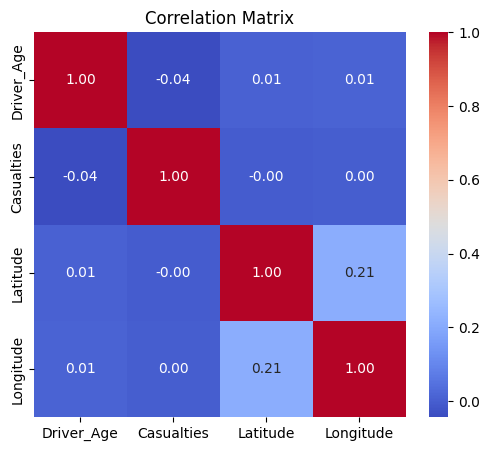

In [33]:
plt.figure(figsize=(6,5))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Matrix")

plt.show()

In [36]:
state_variance = df.groupby('State')['Driver_Age'].var()

print(state_variance)

State
Andhra Pradesh    149.907303
Karnataka         146.922078
Kerala            146.110529
Puducherry        155.963312
Tamil Nadu        144.391338
Telangana         147.406581
Name: Driver_Age, dtype: float64


In [37]:
road_variance = df.groupby('Road_Type')['Driver_Age'].var()

print(road_variance)

Road_Type
City Road           144.155308
Expressway          155.148294
National Highway    150.467937
State Highway       144.936376
Village Road        146.665791
Name: Driver_Age, dtype: float64


In [38]:
gender_variance = df.groupby('Driver_Gender')['Driver_Age'].var()

print(gender_variance)

Driver_Gender
Female    146.302139
Male      147.448424
Name: Driver_Age, dtype: float64


In [39]:
print("State variance-----")
print(state_variance)

print('Road variance------')
print(road_variance)

print("Gender variance-----")
print(gender_variance)

State variance-----
State
Andhra Pradesh    149.907303
Karnataka         146.922078
Kerala            146.110529
Puducherry        155.963312
Tamil Nadu        144.391338
Telangana         147.406581
Name: Driver_Age, dtype: float64
Road variance------
Road_Type
City Road           144.155308
Expressway          155.148294
National Highway    150.467937
State Highway       144.936376
Village Road        146.665791
Name: Driver_Age, dtype: float64
Gender variance-----
Driver_Gender
Female    146.302139
Male      147.448424
Name: Driver_Age, dtype: float64


In [12]:
df1.isnull().sum()

Accident_ID          0
Date                 0
Time                 0
State                0
District             0
Latitude             0
Longitude            0
Road_Type            0
Weather              0
Light_Condition      0
Driver_Age           0
Driver_Gender        0
Vehicle_Type         0
Speed_kmph           0
Alcohol_Involved     0
Driver_Drowsy        0
Pothole_Involved     0
Cause_of_Accident    0
Severity             0
Casualties           0
dtype: int64

In [13]:
df1.info()

<class 'pandas.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Accident_ID        20000 non-null  str    
 1   Date               20000 non-null  str    
 2   Time               20000 non-null  str    
 3   State              20000 non-null  str    
 4   District           20000 non-null  str    
 5   Latitude           20000 non-null  float64
 6   Longitude          20000 non-null  float64
 7   Road_Type          20000 non-null  str    
 8   Weather            20000 non-null  str    
 9   Light_Condition    20000 non-null  str    
 10  Driver_Age         20000 non-null  int64  
 11  Driver_Gender      20000 non-null  str    
 12  Vehicle_Type       20000 non-null  str    
 13  Speed_kmph         20000 non-null  int64  
 14  Alcohol_Involved   20000 non-null  str    
 15  Driver_Drowsy      20000 non-null  str    
 16  Pothole_Involved   20000 non-null

In [14]:
df1['Date']=pd.to_datetime(df1['Date'])

In [16]:
df1.to_csv("Road_Accident_Data_Set.csv",index=False)

In [17]:
df1.head()

,Accident_ID,Date,Time,State,District,Latitude,Longitude,Road_Type,Weather,Light_Condition,Driver_Age,Driver_Gender,Vehicle_Type,Speed_kmph,Alcohol_Involved,Driver_Drowsy,Pothole_Involved,Cause_of_Accident,Severity,Casualties
0,ACC20000,2023-01-18,12:39,Tamil Nadu,Madurai,11.2765,78.0398,Village Road,Rainy,Day,18,Male,Auto,39,No,No,No,Poor Weather Visibility,Low,2
1,ACC20001,2023-10-16,18:13,Andhra Pradesh,Guntur,16.2785,79.6676,National Highway,Cloudy,Dusk,34,Male,Bus,83,No,No,No,Over Speeding,Medium,0
2,ACC20002,2024-05-17,14:28,Karnataka,Mysuru,14.4623,75.0246,Village Road,Rainy,Day,47,Female,Bike,50,Yes,No,Yes,Poor Weather Visibility,High,7
3,ACC20003,2023-05-15,7:54,Andhra Pradesh,Visakhapatnam,15.6972,80.1319,National Highway,Cloudy,Day,53,Male,Bus,65,No,No,No,Poor Weather Visibility,Medium,3
4,ACC20004,2023-11-08,9:05,Puducherry,Puducherry,11.7264,80.7346,State Highway,Cloudy,Day,38,Male,Car,80,No,No,No,Over Speeding,Low,1
